# 249. Group Shifted Strings
https://leetcode.com/problems/group-shifted-strings/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Hash by Shift Key** | **O(n * k)** | **O(n * k)** | **Compute difference key for each string, group by key** |

## Methodology

Two strings belong to the same shifting sequence if the **differences between consecutive characters** (mod 26) are the same. We compute a **canonical key** for each string: the tuple of character differences mod 26. Strings with the same key are grouped together using a hash map.

## Solutions

### C#

In [ ]:
// 249. Group Shifted Strings
// Time: O(n * k) | Space: O(n * k)
public class Solution {
    public IList<IList<string>> GroupStrings(string[] strings) {
        var groups = new Dictionary<string, IList<string>>();
        
        foreach (string s in strings) {
            var key = GetKey(s);
            if (!groups.ContainsKey(key))
                groups[key] = new List<string>();
            groups[key].Add(s);
        }
        
        return new List<IList<string>>(groups.Values);
    }
    
    private string GetKey(string s) {
        var sb = new System.Text.StringBuilder();
        for (int i = 1; i < s.Length; i++) {
            int diff = (s[i] - s[i-1] + 26) % 26;
            sb.Append(diff).Append(',');
        }
        return sb.ToString();
    }
}

### Python

In [ ]:
# 249. Group Shifted Strings
# Time: O(n * k) | Space: O(n * k)
from collections import defaultdict

class Solution:
    def groupStrings(self, strings: list[str]) -> list[list[str]]:
        groups = defaultdict(list)
        
        for s in strings:
            key = tuple((ord(s[i]) - ord(s[i-1])) % 26 for i in range(1, len(s)))
            groups[key].append(s)
        
        return list(groups.values())

### Go

In [ ]:
// 249. Group Shifted Strings
// Time: O(n * k) | Space: O(n * k)
import "fmt"

func groupStrings(strings []string) [][]string {
    groups := make(map[string][]string)
    
    for _, s := range strings {
        key := getKey(s)
        groups[key] = append(groups[key], s)
    }
    
    result := make([][]string, 0, len(groups))
    for _, group := range groups {
        result = append(result, group)
    }
    return result
}

func getKey(s string) string {
    key := ""
    for i := 1; i < len(s); i++ {
        diff := (int(s[i]) - int(s[i-1]) + 26) % 26
        key += fmt.Sprintf("%d,", diff)
    }
    return key
}

### Rust

In [ ]:
// 249. Group Shifted Strings
// Time: O(n * k) | Space: O(n * k)
use std::collections::HashMap;

impl Solution {
    pub fn group_strings(strings: Vec<String>) -> Vec<Vec<String>> {
        let mut groups: HashMap<Vec<u8>, Vec<String>> = HashMap::new();
        
        for s in strings {
            let bytes = s.as_bytes();
            let key: Vec<u8> = (1..bytes.len())
                .map(|i| (bytes[i] as i32 - bytes[i-1] as i32 + 26) as u8 % 26)
                .collect();
            groups.entry(key).or_default().push(s);
        }
        
        groups.into_values().collect()
    }
}

## Example Scenarios

1. **Common Case** — Mixed-length strings with clear shift groups  
   **Input:** `strings = ["abc", "bcd", "acef", "xyz", "az", "ba", "a", "z"]`  
   Compute shift keys: "abc" → $(1,1)$, "bcd" → $(1,1)$, "xyz" → $(1,1)$. They group together. "az" → $(25)$, "ba" → $(25)$ (since $a - b = -1 \equiv 25 \pmod{26}$). Single chars "a", "z" share key $()$. Result: 4 groups.

2. **Slightly Complex** — Wraparound shifts near alphabet boundary  
   **Input:** `strings = ["za", "yb", "xc", "ab"]`  
   "za" → shift key $(1)$ because $a - z = 1 \pmod{26}$. Similarly "yb" → $(3)$, "xc" → $(5)$, "ab" → $(1)$. So "za" and "ab" group together, while "yb" and "xc" are each alone. Result: 3 groups.

3. **Edge Case: Time Factor** — Large input with all unique shift patterns  
   **Input:** `strings` contains $10^4$ strings, each with a unique shift difference sequence  
   Every string maps to a distinct key. We compute $O(n \times k)$ total characters across all strings. The hash map has $10^4$ entries, each with a single-element list. Full scan with no grouping benefit.

4. **Edge Case: Space Factor** — All strings collapse into one group  
   **Input:** `strings = ["a", "b", "c", ..., "z"]` (26 single-character strings)  
   Every single character has the empty tuple $()$ as its key. The hash map stores one entry with all 26 strings. Space is dominated by the single large bucket.

5. **Almost-Impossible but Plausible** — Strings at maximum length with identical diffs  
   **Input:** `strings = ["a" * 50, "b" * 50, ..., "z" * 50]`  
   Each string is 50 identical characters. Shift key for all: $(0, 0, \ldots, 0)$ (49 zeros). All 26 strings land in the same group. The $49$-element tuple key is hashed $26$ times.


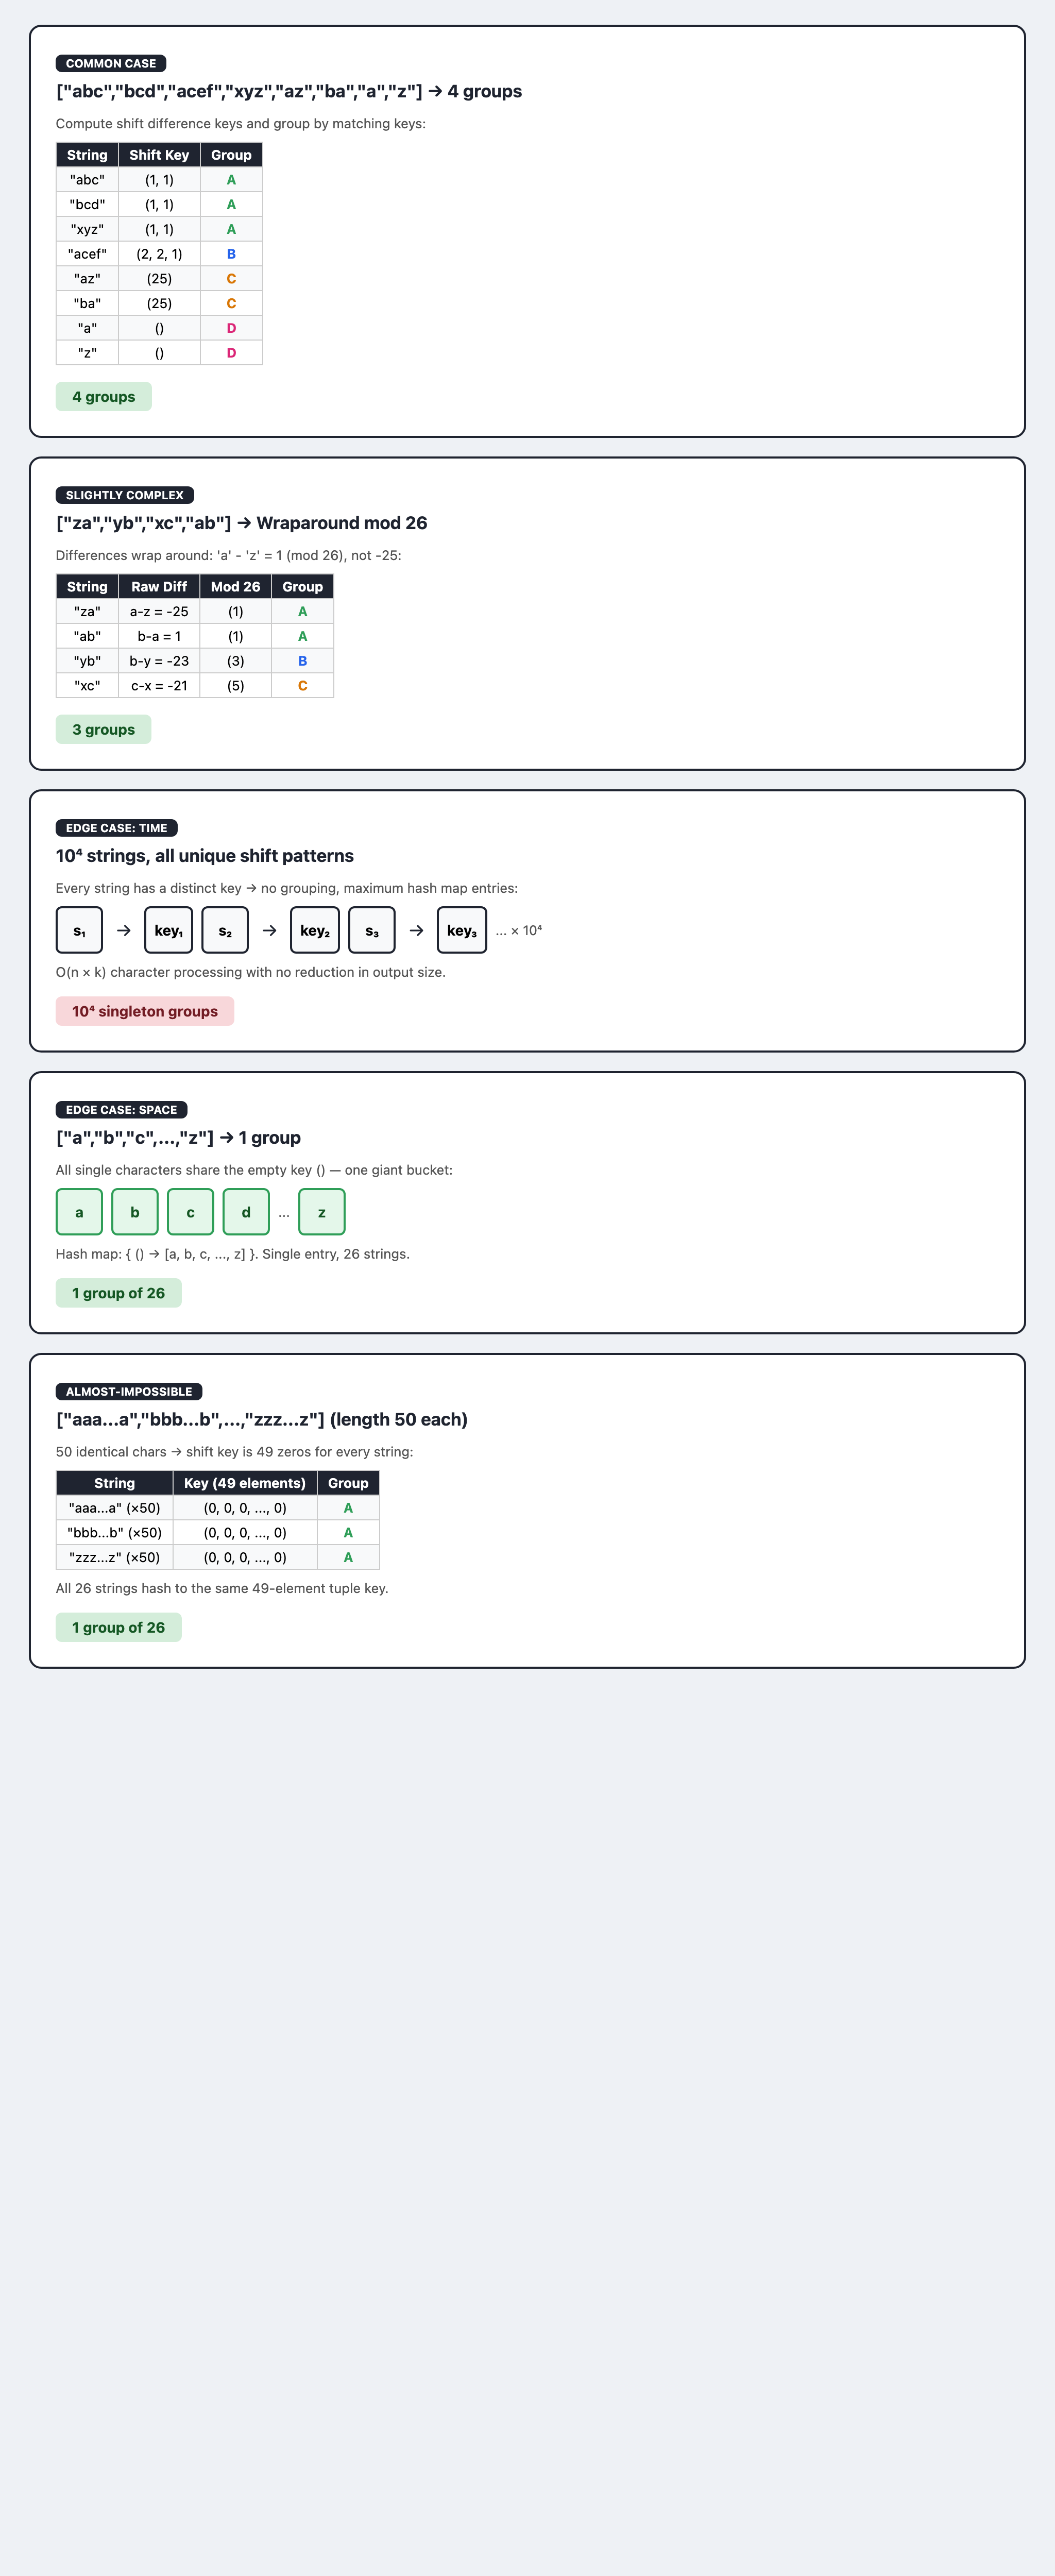